In [35]:
import numpy as np

class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
       
        self.betas = beta_matrix
        self.comp_designs = competitor_designs
        self.market_size = market_size
        
        # Pre-calculate competitor utilities since they remain constant
        # Resulting matrix: (num_respondents, num_competitors)
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    def evaluate_product(self, our_design, our_price, our_cost, price_betas): #Setup main function with inputs expected 
        """
        Evaluates a new product configuration generated by NSGA-II.
        
        our_design: A 2D array of shape (1, num_attribute_levels)
        our_price: Float representing the product price
        our_cost: Float representing the product cost
        """
        # Calculate utility for our new product
        # Resulting matrix: (num_respondents, 1)
        feature_utility = np.dot(self.betas, our_design.T)

        #Adding Price negativity
        #price_betas shape: (num_respondents, 1)
        price_utilities = price_betas * our_price
        our_utility = feature_utility + price_utilities
        
        # Combine all utilities into a single matrix
        # Resulting matrix: (num_respondents, num_competitors + 1)
        all_utilities = np.hstack((self.comp_utilities, our_utility))
        
        # Apply Multinomial Logit (MNL) rule
        exp_utilities = np.exp(all_utilities)
        probabilities = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        
        # Extract the probability column for our product (the last column)
        our_probabilities = probabilities[:, -1]
        
        # Calculate final objectives
        market_share = np.mean(our_probabilities)
        unit_sales = market_share * self.market_size
        profit = unit_sales * (our_price - our_cost)
        
        return market_share, profit

In [36]:
# Dummy survey
np.random.seed(42) 
num_respondents = 100
num_attribute_levels = 7
dummy_betas = np.random.normal(loc=0.0, scale=1.5, size=(num_respondents, num_attribute_levels)) #Generating dummy beta values, to be replaced by input

market_size = 50000 

# Generate negative price sensitivities for 100 respondents
# Average sensitivity is -0.8 utility points per dollar
price_betas = np.random.normal(loc=-0.8, scale=0.2, size=(num_respondents, 1))

# Define competitor prices
# Competitor A ($2.00) and Competitor B ($3.50)
comp_prices = np.array([[2.00], [3.50]]) 

# Update the competitor utility calculation to include their prices
# (num_respondents, num_competitors) + (num_respondents, 1) * (1, num_competitors)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)

# Competitor A: 1.25mm, 3A, 50 cycles  -> [1, 0, 0,  1, 0,  1, 0]
# Competitor B: 2.50mm, 5A, 100 cycles -> [0, 0, 1,  0, 1,  0, 1]
competitor_matrix = np.array([
    [1, 0, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1, 0, 1]
])

# Initialize the Simulator
simulator = MarketSimulator(dummy_betas, competitor_matrix, market_size)

# Our Product: 2.00mm, 5A, 50 cycles -> [0, 1, 0,  0, 1,  1, 0]
our_new_design = np.array([[0, 1, 0, 0, 1, 1, 0]]) 
our_price = 2.50
our_cost = 0.85

# Running the evaluation
market_share, profit = simulator.evaluate_product(our_new_design, our_price, our_cost, price_betas)

# Output
print(f"Product Design String: {our_new_design[0]}")
print(f"Price: ${our_price:.2f} | Cost: ${our_cost:.2f}")
print(f"Calculated Market Share: {market_share * 100:.2f}%")
print(f"Projected Profit: ${profit:,.2f}")

Product Design String: [0 1 0 0 1 1 0]
Price: $2.50 | Cost: $0.85
Calculated Market Share: 15.01%
Projected Profit: $12,380.98


In [ ]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import numpy as np

class Optimizer(ElementwiseProblem):
    def __init__(self, sim, price_betas):
        super().__init__(n_var=4, n_obj=2, 
                         xl=np.array([0, 0, 0, 1.0]), 
                         xu=np.array([2, 1, 1, 5.0]))
        self.sim = sim
        self.price_betas = price_betas 

    def _evaluate(self, x, out, *args, **kwargs):
        design = np.zeros((1, 7))
        design[0, int(round(x[0]))] = 1          
        design[0, 3 + int(round(x[1]))] = 1      
        design[0, 5 + int(round(x[2]))] = 1      

        share, profit = self.sim.evaluate_product(design, x[3], 0.85, self.price_betas)
        out["F"] = [-share, -profit]

# --- Execute and Print ---
res = minimize(Optimizer(simulator, price_betas), NSGA2(pop_size=100), ('n_gen', 10000))

print(f"Found {len(res.F)} optimal solutions:\n" + "-"*45)

for share, profit, price in zip(-res.F[:, 0], -res.F[:, 1], res.X[:, 3]):
    print(f"Share: {share*100:5.2f}% | Profit: ${profit:8.2f} | Price: ${price:5.2f}")

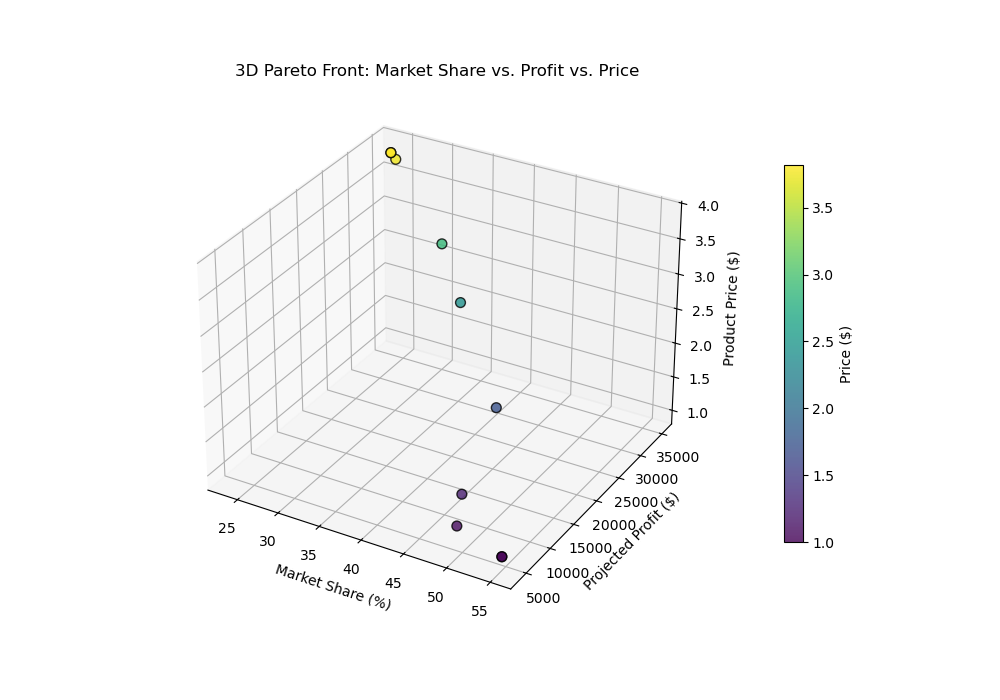

In [40]:
import matplotlib.pyplot as plt

# Extract the final values from your Pymoo results
market_share = -res.F[:, 0] * 100
profit = -res.F[:, 1]
prices = res.X[:, 3]

# Set up the 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
# Using a subtle color gradient along the Z-axis (price) for extra clarity
scatter = ax.scatter(market_share, profit, prices, c=prices, cmap='viridis', s=50, alpha=0.8, edgecolors='black')

# Add professional labels and formatting
ax.set_title("3D Pareto Front: Market Share vs. Profit vs. Price")
ax.set_xlabel("Market Share (%)")
ax.set_ylabel("Projected Profit ($)")
ax.set_zlabel("Product Price ($)")

# Add a color bar legend for the exact price values
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Price ($)")

# Display the interactive 3D graph
plt.show()